зафиксируем Seed, выберем устройство, на котором будет выполняться обучение

In [1]:
# Базовые библиотеки
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# Датасеты / трансформации
import torchvision
from torchvision import transforms

# Повторяемость
SEED = 42


random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('torch:', torch.__version__)
print("torchvision:", torchvision.__version__)

# Размер батча подстроим под наличие GPU
BATCH_SIZE = 1024 if device.type == "cuda" else 64

# На Windows в Jupyter иногда бывают проблемы с multiprocessing в DataLoader.
# Поэтому автоматически ставим num_workers=0 на Windows, иначе 2.
NUM_WORKERS = 0 if os.name == "nt" else 2
#NUM_WORKERS = os.cpu_count() // 2

ModuleNotFoundError: No module named 'torch'

Загрузка выбранного датасета

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),  # mean/std для 1 канала
])

train_full = torchvision.datasets.EMNIST(
    root = "./data", train=True, download=True, transform=transform, split="balanced"
)

test_ds = torchvision.datasets.EMNIST(
    root = "./data", train=False, download=True, transform=transform, split="balanced"
)

class_names = train_full.classes

print("classes:", class_names)
print("train size:", len(train_full))
print("test size:", len(test_ds))

classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
train size: 112800
test size: 18800


In [ ]:
val_ratio = 0.2
val_size = int(len(train_full)*val_ratio)
train_size = len(train_full)-val_size

gen = torch.Generator().manual_seed(SEED)

train_ds, val_ds = random_split(
    train_full, [train_size, val_size], generator=gen
)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda")
)

val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda")
)

test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda")
)

# Быстрый sanity-check
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)
print("batch_size: ", x_batch.shape[0])
print(f"min/max x_batch units: {x_batch.min().item():.4f}/{x_batch.max().item():.4f}")
print(f"min/max y_batch units: {y_batch.min().item():.4f}/{y_batch.max().item():.4f}")

x_batch: torch.Size([1024, 1, 28, 28]) torch.float32
y_batch: torch.Size([1024]) torch.int64
batch_size:  1024
min/max x_batch units: -1.0000/1.0000
min/max y_batch units: 0.0000/46.0000


Реализация MLP и цикла обучкния

In [ ]:
class MLP (nn.Module):
    def __init__(
            self,
            input_dim: int = 28*28,
            hidden_dims: tuple = (256, 128),
            num_clusses: int = 47, ######################
            activation: str = "relu",
            dropout_p: float = 0.0,
            use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = torch.nn.ReLU
        else:
            raise ValueError(f"Unknown activation: {activation}")
        
        layers = [nn.Flatten()]

        prev = input_dim

        for h in hidden_dims:
            layers.append(torch.nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(torch.nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(torch.nn.Dropout(p=dropout_p))
            prev = h
        
        layers.append(torch.nn.Linear(prev, num_clusses))
        self.net = torch.nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)
    
model = MLP().to(device)

In [ ]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0
    
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1
    
    return total_loss / n_batches, total_acc / n_batches

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval() # режим рассчета, выключает Droput и batchNorm
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [ ]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


In [ ]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

### 3.1. Часть А

In [ ]:
criterion = torch.nn.CrossEntropyLoss()

modelE1 = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False).to(device)
optimizer1 = optim.Adam(modelE1.parameters(), lr=1e-3)
modelE2 = MLP(hidden_dims=(256, 128), dropout_p=0.35, use_batchnorm=False).to(device)
optimizer2 = optim.Adam(modelE2.parameters(), lr=1e-3)
modelE3 = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)
optimizer3 = optim.Adam(modelE3.parameters(), lr=1e-3)

history_modelE1 = fit(
    modelE1, train_loader, val_loader,
    optimizer1, criterion, device,
    epochs=20,
    early_stopping=None
)

history_modelE2 = fit(
    modelE2, train_loader, val_loader,
    optimizer2, criterion, device,
    epochs=20,
    early_stopping=None,
    verbose=False,
)

history_modelE3 = fit(
    modelE3, train_loader, val_loader,
    optimizer3, criterion, device,
    epochs=20,
    early_stopping=None,
    verbose=False,
)



test_loss, test_acc = evaluate(modelE1, test_loader, criterion, device)
print(f"modelE1 test: loss={test_loss:.4f}, acc={test_acc:.4f}")

test_loss, test_acc = evaluate(modelE2, test_loader, criterion, device)
print(f"modelE2 test: loss={test_loss:.4f}, acc={test_acc:.4f}")

test_loss, test_acc = evaluate(modelE3, test_loader, criterion, device)
print(f"modelE3 test: loss={test_loss:.4f}, acc={test_acc:.4f}")

epoch 01/20 | train loss=1.9897, acc=0.4791 | val loss=1.3132, acc=0.6281
epoch 02/20 | train loss=1.1851, acc=0.6596 | val loss=1.0662, acc=0.6898
epoch 03/20 | train loss=0.9840, acc=0.7131 | val loss=0.9094, acc=0.7331
epoch 04/20 | train loss=0.8419, acc=0.7486 | val loss=0.7969, acc=0.7666
epoch 05/20 | train loss=0.7508, acc=0.7727 | val loss=0.7633, acc=0.7666
epoch 06/20 | train loss=0.6827, acc=0.7904 | val loss=0.7110, acc=0.7801
epoch 07/20 | train loss=0.6291, acc=0.8034 | val loss=0.6552, acc=0.7959
epoch 08/20 | train loss=0.5927, acc=0.8127 | val loss=0.6259, acc=0.8074
epoch 09/20 | train loss=0.5615, acc=0.8213 | val loss=0.5995, acc=0.8141
epoch 10/20 | train loss=0.5347, acc=0.8280 | val loss=0.5876, acc=0.8148
epoch 11/20 | train loss=0.5104, acc=0.8329 | val loss=0.5541, acc=0.8227
epoch 12/20 | train loss=0.4919, acc=0.8378 | val loss=0.5463, acc=0.8230
epoch 13/20 | train loss=0.4698, acc=0.8452 | val loss=0.5497, acc=0.8239
epoch 14/20 | train loss=0.4550, acc=0

по acc лучше всего себя показала модель modelE3

In [ ]:
modelE4 = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)
optimizer4 = optim.Adam(modelE4.parameters(), lr=1e-3)

es = EarlyStopping(min_delta=0.0005)

history_modelE4 = fit(
    modelE4, train_loader, val_loader,
    optimizer4, criterion, device,
    epochs=20,
    early_stopping=es,
    verbose=True,
)

test_loss, test_acc = evaluate(modelE4, test_loader, criterion, device)
print(f"modelE4 test: loss={test_loss:.4f}, acc={test_acc:.4f}")

tmp_path = 'artifacts\\best_model.pt'
torch.save(modelE4.state_dict(), tmp_path)

epoch 01/20 | train loss=1.7742, acc=0.6195 | val loss=1.1348, acc=0.7030
epoch 02/20 | train loss=0.7702, acc=0.7873 | val loss=0.7244, acc=0.7896
epoch 03/20 | train loss=0.5737, acc=0.8251 | val loss=0.5982, acc=0.8086
epoch 04/20 | train loss=0.4855, acc=0.8461 | val loss=0.5557, acc=0.8207
epoch 05/20 | train loss=0.4316, acc=0.8587 | val loss=0.5375, acc=0.8240
epoch 06/20 | train loss=0.3921, acc=0.8698 | val loss=0.5163, acc=0.8328
epoch 07/20 | train loss=0.3641, acc=0.8765 | val loss=0.5045, acc=0.8385
epoch 08/20 | train loss=0.3381, acc=0.8838 | val loss=0.4979, acc=0.8353
epoch 09/20 | train loss=0.3173, acc=0.8908 | val loss=0.4915, acc=0.8360
epoch 10/20 | train loss=0.3016, acc=0.8944 | val loss=0.4795, acc=0.8382
epoch 11/20 | train loss=0.2855, acc=0.8994 | val loss=0.4817, acc=0.8392
epoch 12/20 | train loss=0.2747, acc=0.9021 | val loss=0.4910, acc=0.8356
epoch 13/20 | train loss=0.2603, acc=0.9077 | val loss=0.5079, acc=0.8362
epoch 14/20 | train loss=0.2491, acc=0

In [ ]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "") -> None:
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

epoch 01/8 | train loss=1.2004, acc=0.6537 | val loss=0.8841, acc=0.7239
epoch 02/8 | train loss=0.6525, acc=0.7875 | val loss=0.7439, acc=0.7694
epoch 03/8 | train loss=0.5618, acc=0.8112 | val loss=0.7199, acc=0.7658
epoch 04/8 | train loss=0.5097, acc=0.8251 | val loss=0.6609, acc=0.7876
epoch 05/8 | train loss=0.4729, acc=0.8343 | val loss=0.6222, acc=0.7993
epoch 06/8 | train loss=0.4462, acc=0.8413 | val loss=0.6023, acc=0.8098
epoch 07/8 | train loss=0.4232, acc=0.8487 | val loss=0.5940, acc=0.8099
epoch 08/8 | train loss=0.4114, acc=0.8521 | val loss=0.6322, acc=0.8059


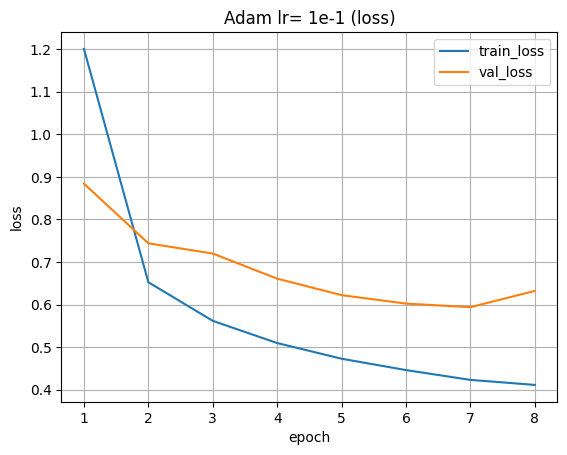

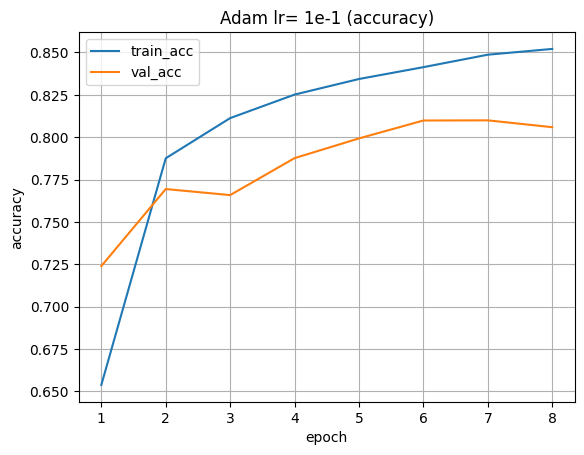

In [ ]:
modelB1 = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)
optimizerB1 = optim.Adam(modelB1.parameters(), lr=1e-1)

history_modelB1 = fit(
    modelB1, train_loader, val_loader,
    optimizerB1, criterion, device,
    epochs=8,
    early_stopping=None
)

plot_history(history_modelB1, "Adam lr= 1e-1")

С большим lr эффект переобучения достигается на первых эпохах, получаем неработоспособную модель за пределами обучаемой выборки.

epoch 01/8 | train loss=3.8160, acc=0.0525 | val loss=3.6994, acc=0.0782
epoch 02/8 | train loss=3.6046, acc=0.1120 | val loss=3.5069, acc=0.1528
epoch 03/8 | train loss=3.4259, acc=0.1928 | val loss=3.3419, acc=0.2375
epoch 04/8 | train loss=3.2739, acc=0.2712 | val loss=3.1997, acc=0.3060
epoch 05/8 | train loss=3.1482, acc=0.3332 | val loss=3.0808, acc=0.3601
epoch 06/8 | train loss=3.0394, acc=0.3842 | val loss=2.9872, acc=0.4036
epoch 07/8 | train loss=2.9423, acc=0.4237 | val loss=2.9013, acc=0.4387
epoch 08/8 | train loss=2.8565, acc=0.4555 | val loss=2.8087, acc=0.4780


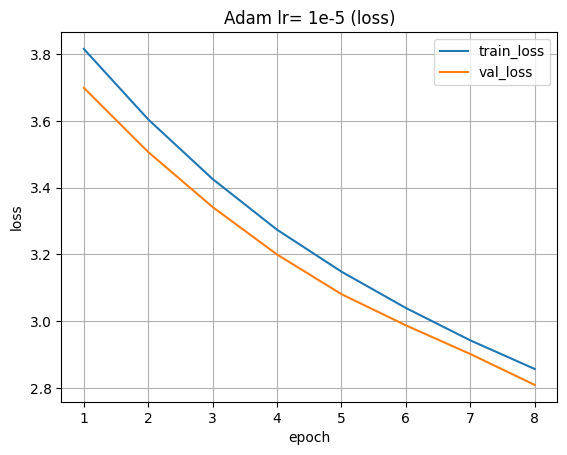

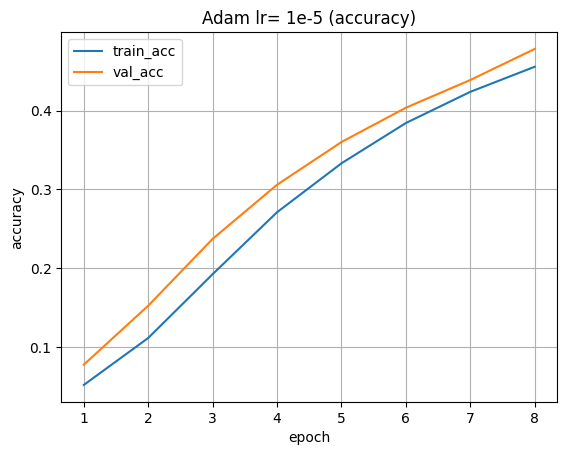

In [ ]:
modelB2 = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)
optimizerB2 = optim.Adam(modelB2.parameters(), lr=1e-5)

history_modelB2 = fit(
    modelB2, train_loader, val_loader,
    optimizerB2, criterion, device,
    epochs=8,
    early_stopping=None
)

plot_history(history_modelB2, "Adam lr= 1e-5")

Обучение почти не двигается, даже на тренировочной выборке результаты слишком низкие

epoch 01/15 | train loss=3.5696, acc=0.1427 | val loss=3.2178, acc=0.3112
epoch 02/15 | train loss=3.0034, acc=0.4017 | val loss=2.7988, acc=0.4536
epoch 03/15 | train loss=2.6528, acc=0.4887 | val loss=2.4920, acc=0.5199
epoch 04/15 | train loss=2.3773, acc=0.5380 | val loss=2.2628, acc=0.5523
epoch 05/15 | train loss=2.1528, acc=0.5724 | val loss=2.0607, acc=0.5876
epoch 06/15 | train loss=1.9670, acc=0.5976 | val loss=1.8684, acc=0.6146
epoch 07/15 | train loss=1.8076, acc=0.6212 | val loss=1.7495, acc=0.6245
epoch 08/15 | train loss=1.6740, acc=0.6392 | val loss=1.6229, acc=0.6491
epoch 09/15 | train loss=1.5611, acc=0.6553 | val loss=1.5123, acc=0.6659
epoch 10/15 | train loss=1.4634, acc=0.6706 | val loss=1.4202, acc=0.6752
epoch 11/15 | train loss=1.3785, acc=0.6839 | val loss=1.3596, acc=0.6826
epoch 12/15 | train loss=1.3039, acc=0.6957 | val loss=1.2797, acc=0.6965
epoch 13/15 | train loss=1.2406, acc=0.7057 | val loss=1.2415, acc=0.6969
epoch 14/15 | train loss=1.1840, acc=0

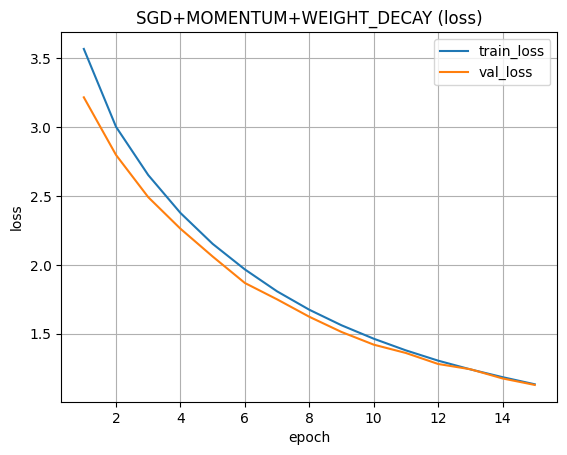

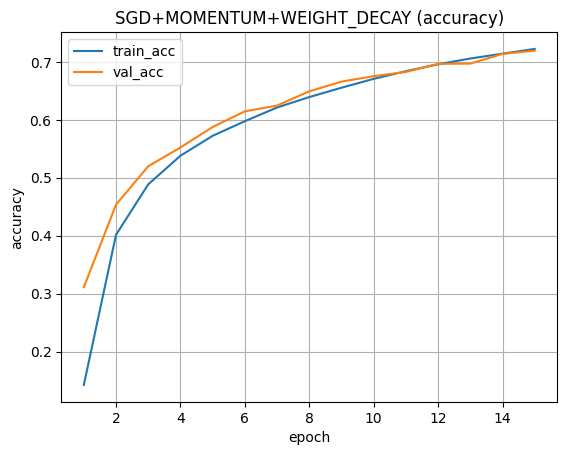

In [ ]:
modelB3 = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)
optimizerB3 = optim.SGD(modelB3.parameters(), lr=1e-3, momentum=0.9, weight_decay=1e-4)

history_modelB3 = fit(
    modelB3, train_loader, val_loader,
    optimizerB3, criterion, device,
    epochs=15,
    early_stopping=None
)

plot_history(history_modelB3, "SGD+MOMENTUM+WEIGHT_DECAY")

In [ ]:
# Artifact generation for runs and plots
import json
import pandas as pd
import matplotlib.pyplot as plt

# Collect experiment info
dataset = "EMNIST"  # used throughout
seed = SEED

# helper to summarize model config

def summarize_model(model):
    # assume it's MLP with attributes
    hidden = []
    activation = None
    dropout = 0.0
    batchnorm = False
    for layer in model.net:
        if isinstance(layer, torch.nn.Linear):
            hidden.append(layer.out_features)
        if isinstance(layer, torch.nn.Dropout):
            dropout = layer.p
        if isinstance(layer, torch.nn.BatchNorm1d):
            batchnorm = True
        if isinstance(layer, torch.nn.ReLU):
            activation = "relu"
    # remove last linear from hidden list since it's output layer
    if hidden:
        hidden = hidden[:-1]
    hidden_str = "x".join(str(h) for h in hidden)
    return f"hidden={hidden_str} act={activation} drop={dropout} bn={batchnorm}"

# get best metrics from history
def best_metrics(history):
    idx = min(range(len(history["val_loss"])), key=lambda i: history["val_loss"][i])
    return {
        "best_val_accuracy": history["val_acc"][idx],
        "best_val_loss": history["val_loss"][idx],
        "epochs_trained": idx + 1,
    }

records = []
for exp_id, model, optimizer, history in [
    ("E1", modelE1, optimizer1, history_modelE1),
    ("E2", modelE2, optimizer2, history_modelE2),
    ("E3", modelE3, optimizer3, history_modelE3),
    ("E4", modelE4, optimizer4, history_modelE4),
    ("O1", modelB1, optimizerB1, history_modelB1),
    ("O2", modelB2, optimizerB2, history_modelB2),
    ("O3", modelB3, optimizerB3, history_modelB3),
]:
    lr = optimizer.param_groups[0]["lr"]
    momentum = optimizer.param_groups[0].get("momentum", 0)
    weight_decay = optimizer.param_groups[0].get("weight_decay", 0)

    rec = {
        "experiment_id": exp_id,
        "dataset": dataset,
        "seed": seed,
        "model_summary": summarize_model(model),
        "optimizer": type(optimizer).__name__,
        "lr": lr,
        "momentum": momentum,
        "weight_decay": weight_decay,
    }
    rec.update(best_metrics(history))
    records.append(rec)

# save csv
runs_df = pd.DataFrame(records)
runs_df.to_csv("runs.csv", index=False)
print("Saved runs.csv with experiments:")
print(runs_df)

# save best config
best_cfg = {
    "experiment_id": "E4",
    "dataset": dataset,
    "seed": seed,
    "model": {
        "hidden_dims": (256, 128),
        "dropout": 0.0,
        "use_batchnorm": True,
        "activation": "relu",
        "input_dim": 28*28,
        "num_classes": 47,
    },
    "optimizer": {
        "type": "Adam",
        "lr": 1e-3,
        "momentum": 0,
        "weight_decay": 0,
    },
    "epochs_trained": best_metrics(history_modelE4)["epochs_trained"],
    "best_val_accuracy": best_metrics(history_modelE4)["best_val_accuracy"],
    "best_val_loss": best_metrics(history_modelE4)["best_val_loss"],
}
with open("best_config.json","w") as f:
    json.dump(best_cfg, f, indent=2)
print("Saved best_config.json")

# plot curves
ios = __import__("os")
plt.figure(figsize=(6,4))
e = history_modelE4
epochs = range(1, len(e["train_loss"])+1)
plt.plot(epochs, e["train_loss"], label="train_loss")
plt.plot(epochs, e["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("E4 loss curves")
plt.grid(True)
ios.makedirs("figures", exist_ok=True)
plt.savefig("figures/curves_best.png")
plt.close()
print("Saved curves_best.png")

# lr extremes
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
e = history_modelB1
epochs = range(1, len(e["train_loss"])+1)
plt.plot(epochs, e["train_loss"], label="train_loss")
plt.plot(epochs, e["val_loss"], label="val_loss")
plt.title("O1 high lr")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
e = history_modelB2
epochs = range(1, len(e["train_loss"])+1)
plt.plot(epochs, e["train_loss"], label="train_loss")
plt.plot(epochs, e["val_loss"], label="val_loss")
plt.title("O2 low lr")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)

plt.savefig("figures/curves_lr_extremes.png")
plt.close()
print("Saved curves_lr_extremes.png")

Saved runs.csv with experiments:
  experiment_id dataset  seed                               model_summary  \
0            E1  EMNIST    42   hidden=256x128 act=relu drop=0.0 bn=False   
1            E2  EMNIST    42  hidden=256x128 act=relu drop=0.35 bn=False   
2            E3  EMNIST    42    hidden=256x128 act=relu drop=0.0 bn=True   
3            E4  EMNIST    42    hidden=256x128 act=relu drop=0.0 bn=True   
4            O1  EMNIST    42    hidden=256x128 act=relu drop=0.0 bn=True   
5            O2  EMNIST    42    hidden=256x128 act=relu drop=0.0 bn=True   
6            O3  EMNIST    42    hidden=256x128 act=relu drop=0.0 bn=True   

  optimizer       lr  momentum  weight_decay  best_val_accuracy  \
0      Adam  0.00100       0.0        0.0000           0.830163   
1      Adam  0.00100       0.0        0.0000           0.823157   
2      Adam  0.00100       0.0        0.0000           0.835470   
3      Adam  0.00100       0.0        0.0000           0.838230   
4      Adam  0.